#### Tarea 3
## Notebook de regresión

En estadistica la regresión es un técnica utilizada apliamente para analizar datos multifactoriales. Su utilidad radica en que permite representar de manera relativamente sencilla la relación entre una variable de interés y un conjunto de variables predictoras. Su principal objetivo es resumir estas relaciones mediante un modelo que facilite la interpretación de los datos y apoye la toma de decisiones (Ángel López Peza, 2024).

En ciencia de datos, esta técnica también tiene un papel importante, ya que puede utilizarse tanto para comprender cómo se relacionan distintas variables como para realizar predicciones. Ante el crecimiento constante en la cantidad de datos disponibles, los modelos de regresión permiten identificar patrones y extraer información relevante que puede ser utilizada para analizar y resolver diferentes problemas.(DASCA, 2024)

Es en este sentido que se hará el desarollo de este notebook, en el cual se aplicará la regresión lineal utilizando el dataset de calidad del vino tinto, con el objetivo de analizar su funcionamiento tanto en un problema de regresión como en uno de clasificación. El dataset **Wine Quality – Red Wine**, proveniente del repositorio UCI Machine Learning. El conjunto contiene 1,599 muestras de vino tinto y 11 características fisicoquímicas, como acidez, azúcar residual, cloruros, pH, alcohol y sulfatos. Además, incluye la variable `quality`, que representa la calidad del vino mediante una puntuación asignada a partir de evaluaciones sensoriales. (Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J., 2009)

### Variables del dataset

| Variable | Descripción |
|---|---|
| `fixed acidity` | Acidez fija del vino, asociada principalmente con ácidos no volátiles. |
| `volatile acidity` | Acidez volátil, relacionada principalmente con la presencia de ácido acético. |
| `citric acid` | Concentración de ácido cítrico. |
| `residual sugar` | Cantidad de azúcar que permanece después de la fermentación. |
| `chlorides` | Concentración de cloruros (sales) en el vino. |
| `free sulfur dioxide` | Cantidad de dióxido de azufre libre (SO₂). |
| `total sulfur dioxide` | Cantidad total de dióxido de azufre (SO₂). |
| `density` | Densidad del vino. |
| `pH` | Medida de la acidez o alcalinidad del vino. |
| `sulphates` | Concentración de sulfatos. |
| `alcohol` | Porcentaje de alcohol presente en el vino. |
| `quality` | Calidad del vino según evaluación sensorial. Es la variable objetivo. |

### Librerias


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

In [62]:
# Cargar el dataset
df = pd.read_csv("winequality-red.csv")

# Visualizar las primeras observaciones
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Regresión

Primero debemos separar nuestra variable objectvo `quality` de las demás, esta va ser nuestra y:

In [63]:
X = df.drop(columns="quality")
y = df["quality"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (1599, 11)
Dimensiones de y: (1599,)


Luego, procedemos a hacer la divsión 80/20 con random_state=42, como marca la tarea:

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (1279, 11)
Prueba: (320, 11)


In [65]:
modelo_reg = LinearRegression()

modelo_reg.fit(X_train, y_train)

y_pred = modelo_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 0.6245
R²: 0.4032


El RMSE = 0.6245 indica que las predicciones se alejan del valor real de quality aproximadamente 0.62 puntos, mientras que R² = 0.4032 indica que el modelo explica aproximadamente 40.3 % de la variabilidad observada en la calidad.

Para determinar si la regresión lineal realmente tiene capacidad predictiva, se usó como referencia un modelo base que predice para todos los vinos la calidad promedio observada en el conjunto de entrenamiento. Este modelo no considera ninguna de las características fisicoquímicas de los vinos, por lo que representa una estrategia de predicción sencilla. 

In [66]:
promedio = y_train.mean()

y_pred_promedio = np.full(len(y_test), promedio)

rmse_promedio = np.sqrt(
    mean_squared_error(y_test, y_pred_promedio)
)

r2_promedio = r2_score(y_test, y_pred_promedio)

print(f"Promedio de entrenamiento: {promedio:.4f}")
print(f"RMSE del promedio: {rmse_promedio:.4f}")
print(f"R² del promedio: {r2_promedio:.4f}")

Promedio de entrenamiento: 5.6239
RMSE del promedio: 0.8107
R² del promedio: -0.0056


La regresión lineal presenta un RMSE menor que el obtenido al predecir siempre el promedio (0.6245 frente a 0.8107). Además, alcanza un R² de aproximadamente 0.403, por lo que las características fisicoquímicas aportan información útil para predecir la calidad.

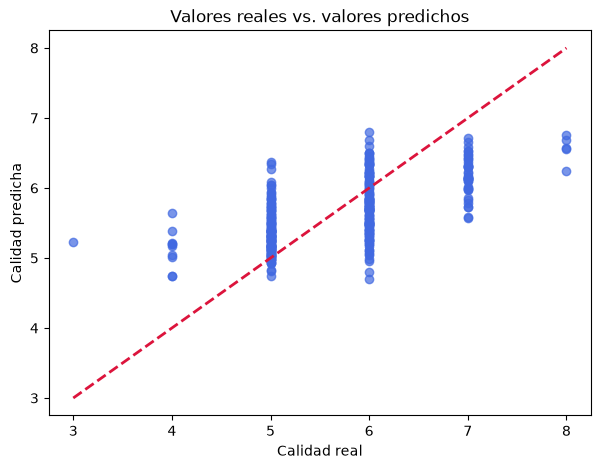

In [67]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, color="royalblue", alpha=0.7)

# Línea de predicción perfecta
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="crimson",
    linewidth=2
)

plt.xlabel("Calidad real")
plt.ylabel("Calidad predicha")
plt.title("Valores reales vs. valores predichos")

plt.show()

En la gráfica se comparan los valores reales de calidad con las predicciones por el modelo. La línea punteada representa el caso ideal en el que la calidad predicha coincide exactamente con la calidad real. Se observa que el modelo presenta un mejor ajuste para los valores intermedios, es decir las calidades de 5 y 6, mientras que tiene mayores dificultades para representar los valores extremos. En particular, tiende a sobreestimar los vinos de menor calidad y a subestimar aquellos de mayor calidad.

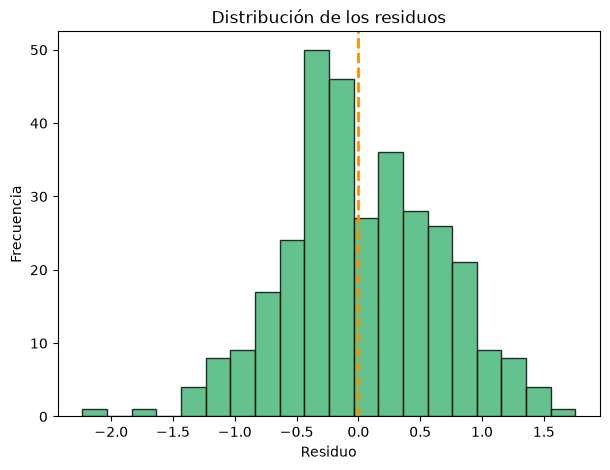

In [68]:
residuos = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.hist(
    residuos,
    bins=20,
    color="mediumseagreen",
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    x=0,
    linestyle="--",
    color="darkorange",
    linewidth=2
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")

plt.show()

La representación de la distribución de los residuos permite observar la magnitud y dirección de los errores producidos por el modelo. Estos de forma ideal deberían concentrarse alrededor de cero, indicando que el modelo no presenta una tendencia general a sobreestimar o subestimar la calidad. como se puede observar la mayor parte de los errores se concentran dentro del intervalo de −1 a 1. Esto indica que la diferencia entre la calidad real y la predicha es relativamente pequeña. Se observan residuos tanto positivos como negativos, lo que significa que el modelo presenta casos de subestimación y sobreestimación, lo que concurre con la gráfica pasada. 

### Clasificación

Después de analizar la variable `quality` con regresión, ahora se abordará el mismo dataset desde clasificación. Para ello, la calidad del vino se transformará en una variable binaria, considerando como **bueno** a aquellos vinos con una calidad mayor o igual a 7 y como **no bueno** al resto. El objetivo será evaluar qué ocurre al utilizar una regresión lineal para resolver un problema donde la salida es una de dos clases posibles.

In [69]:
df["bueno"] = (df["quality"] >= 7).astype(int)

df[["quality", "bueno"]].head()
df["bueno"].value_counts()

bueno
0    1382
1     217
Name: count, dtype: int64

In [70]:
# Quitar tanto quality como bueno de las variables predictoras.
X = df.drop(columns=["quality", "bueno"])
y = df["bueno"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)




In [71]:
modelo_clas = LinearRegression()

modelo_clas.fit(X_train, y_train)

y_pred = modelo_clas.predict(X_test)

In [72]:
y_pred[:10]

array([ 1.10377825e-04, -4.85658602e-02,  1.11880300e-01,  5.30546989e-03,
        1.49163138e-01, -4.77205054e-02, -4.66480391e-02, -1.14083725e-02,
        1.64871696e-01,  1.39249857e-01])

In [73]:
y_pred_clase = (y_pred >= 0.5).astype(int) # umbral de 0.5 para clasificar como bueno o no bueno, estipulado en la tarea

Porcentaje de aciertos: 86.25%


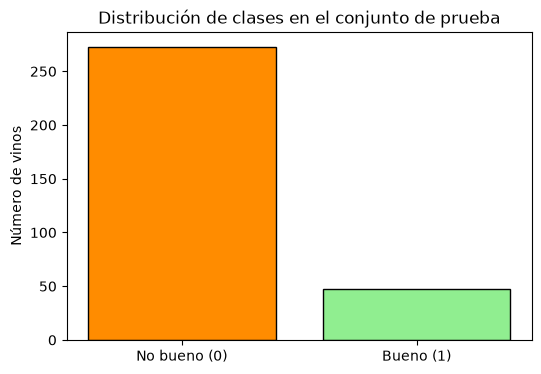

In [76]:
accuracy = accuracy_score(y_test, y_pred_clase)

print(f"Porcentaje de aciertos: {accuracy * 100:.2f}%")

conteo = y_test.value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ["No bueno (0)", "Bueno (1)"],
    [conteo.get(0, 0), conteo.get(1, 0)],
    color=["darkorange", "lightgreen"],
    edgecolor="black"
)

plt.ylabel("Número de vinos")
plt.title("Distribución de clases en el conjunto de prueba")

plt.show()

El modelo obtuvo un porcentaje de aciertos de 86.25 %, y aunque esto puede verse bastante prometedor, no es sufuciente para determinar por sí solo si el modelo presenta un buen desempeño, ya que existe un desbalance entre las clases. Por esta razón, es necesario compararlo con una estrategia base que prediga siempre la clase más frecuente.

In [51]:
y_pred_no_bueno = np.zeros(len(y_test))

accuracy_no_bueno = accuracy_score(
    y_test,
    y_pred_no_bueno
)

print(
    f"Aciertos prediciendo siempre 'no bueno': "
    f"{accuracy_no_bueno * 100:.2f}%"
)

Aciertos prediciendo siempre 'no bueno': 85.31%


Al predecir que todos los vinos pertenecen a la clase «no bueno», se obtiene un porcentaje de aciertos de 85.31 %. Este valor es muy cercano al 86.25 % alcanzado por la regresión lineal, con una diferencia de apenas 0.94%. Esta pequeña diferencia se debe al desbalance de clases, por lo que el alto porcentaje de aciertos del modelo no representa una mejora considerable frente a una estrategia simple.

Predicciones fuera del intervalo [0, 1]: 82
Predicción mínima: -0.1504
Predicción máxima: 0.5439
25.62%


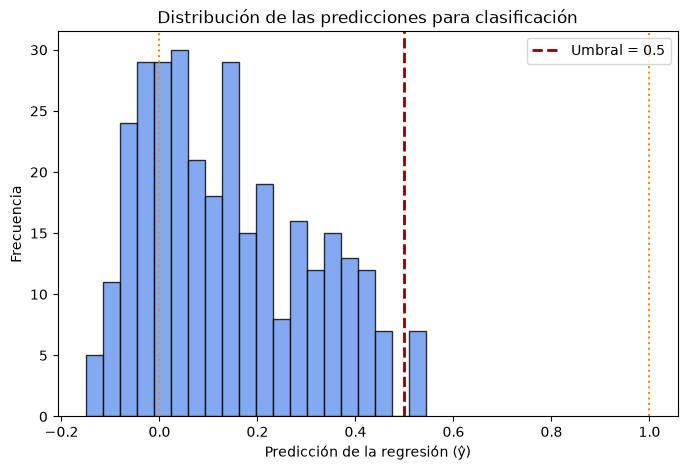

In [77]:
fuera_rango = np.sum((y_pred < 0) | (y_pred > 1))

print(
    f"Predicciones fuera del intervalo [0, 1]: "
    f"{fuera_rango}"
)

print(f"Predicción mínima: {y_pred.min():.4f}")
print(f"Predicción máxima: {y_pred.max():.4f}")
porcentaje_fuera = fuera_rango / len(y_pred) * 100
print(f"{porcentaje_fuera:.2f}%")

plt.figure(figsize=(8, 5))

plt.hist(
    y_pred,
    bins=20,
    color="cornflowerblue",
    edgecolor="black",
    alpha=0.8
)

# Umbral utilizado para clasificar
plt.axvline(
    x=0.5,
    linestyle="--",
    color="darkred",
    linewidth=2,
    label="Umbral = 0.5"
)

# Límites ideales de una probabilidad
plt.axvline(x=0, linestyle=":", color="darkorange", linewidth=1.5)

plt.axvline(x=1, linestyle=":", color="darkorange", linewidth=1.5)

plt.xlabel("Predicción de la regresión (ŷ)")
plt.ylabel("Frecuencia")
plt.title("Distribución de las predicciones para clasificación")
plt.legend()

plt.show()

La gráfica de arriba permite observar cómo la regresión lineal genera valores continuos para una variable objetivo que únicamente puede tomar los valores 0 y 1. Se utiliza un umbral de 0.5 para convertir estas predicciones en las clases **buen** y **no bueno**.De las 320 observaciones de prueba, 82 predicciones (25.63 %) quedaron fuera del intervalo [0, 1], alcanzando un mínimo de −0.1504. 

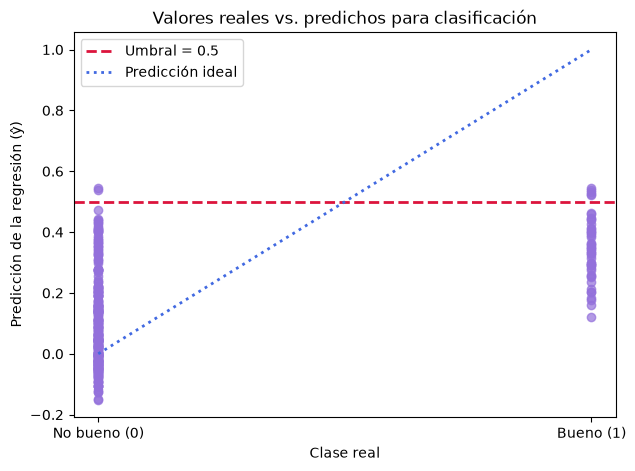

In [80]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred,
    color="mediumpurple",
    alpha=0.7
)

# Umbral de clasificación
plt.axhline(
    y=0.5,
    linestyle="--",
    color="crimson",
    linewidth=2,
    label="Umbral = 0.5"
)

# Línea ideal: predicción = valor real
plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    color="royalblue",
    linewidth=2,
    label="Predicción ideal"
)

plt.xticks([0, 1], ["No bueno (0)", "Bueno (1)"])

plt.xlabel("Clase real")
plt.ylabel("Predicción de la regresión (ŷ)")
plt.title("Valores reales vs. predichos para clasificación")

plt.legend()
plt.show()

La gráfica muestra que las predicciones de la regresión lineal se distribuyen de forma continua, aunque a diferencia del problema de regresión anterior, la variable objetivo solo toma valores de 0 o 1. Algunas predicciones de vinos buenos quedan por debajo del umbral de 0.5 y también aparecen valores negativos, lo que refleja las limitaciones de la regresión lineal en el uso de problemas de clasificación.

### Conclusión 
En el problema de regresión, la variable objetivo representa directamente la calidad del vino como un valor numérico, por lo que la regresión lineal puede utilizarse facilmente para estimar dicho valor y se puede evaluar su desempeño mediante métricas como RMSE y R². En cambio, en el problema de clasificación la variable objetivo únicamente puede tomar dos valores, bueno o no bueno, por lo que es necesario convertir la salida continua de la regresión en una clase utilizando un umbral (que en este caso fuie de 0.5). Aunque el modelo obtuvo un 86.25 % de aciertos, la mejora frente a predecir siempre «no bueno» fue pequeña. Además, varias predicciones quedaron fuera del intervalo [0, 1], mostrando que la regresión lineal no es adecuada para representar probabilidades. Por ello, sería mejor utilizar un modelo diseñado especificamnete para clasificación. 

A pesar de esto, la regresión lineal sigue siendo una herramienta poderosa por su simplicidad, sin embargo, esta tarea demuestra que su efectividad depende del tipo de problema en el que se utilice. Aunque puede adaptarse a tareas de clasificación, sus limitaciones hacen que existan métodos más apropiados para este propósito. Por lo tanto, más que buscar un modelo que funcione para cualquier situación, es importante comprender las características de cada técnica y saber cuándo es adecuado utilizarla.

### Referencias
Angel López Peza, H. (2024). Prsentancion de un grupo | Facultad de Ciencias. https://www.fciencias.unam.mx/docencia/horarios/presentacion/245512

DASCA. (2024, 4 octubre). Essential Regression Analysis Techniques for Data Science. Recuperado 5 de octubre de 2026, de https://www.dasca.org/world-of-data-science/article/essential-regression-analysis-techniques-for-data-science 

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T.

### Declaración de uso de IA
Para el desarrollo de esta práctica se utilizó ChatGPT (OpenAI) como herramienta de apoyo para mejorar la redacción y para orientar algunos procedimientos de análisis y preprocesamiento de datos. Los resultados, el código y las interpretaciones obtenidas fueron revisados y ajustados antes de su incorporación a la práctica. 